In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import matplotlib.ticker as ticker

In [2]:
states = ['Alabama', 'Arizona' ,'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 
         'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
         'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana','Nebraska', 'Nevada', 'New Hampshire',
         'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
         'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
         'West Virginia', 'Wisconsin','Wyoming']
state_codes = ['AL','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN','IA','KS','KY','LA','ME','MD','MA',
              'MI','MN','MS','MO','MT','NE','NV','NH','NJ','NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN',
              'TX','UT','VT','VA','WA','WV','WI','WY']

In [3]:
state_df = pd.DataFrame(states, state_codes) # Create a dataframe
state_df.reset_index(level=0, inplace=True)
state_df.columns = ['State Code','State']

In [4]:
state_df

,State Code,State
0,AL,Alabama
1,AZ,Arizona
2,AR,Arkansas
3,CA,California
4,CO,Colorado
5,CT,Connecticut
6,DE,Delaware
7,FL,Florida
8,GA,Georgia
9,HI,Hawaii


In [5]:
data = pd.read_csv('train.csv')

In [6]:
data.shape
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [7]:
data.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [9]:
data.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [10]:
# data.dropna(inplace=True)

In [11]:
data.drop(columns="Row ID", inplace=True)
data['Order Date'] = pd.to_datetime(data['Order Date'],format="%d/%m/%Y")
data['Ship Date'] = pd.to_datetime(data['Ship Date'],format="%d/%m/%Y")

In [12]:
data.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9800 non-null   object        
 1   Order Date     9800 non-null   datetime64[ns]
 2   Ship Date      9800 non-null   datetime64[ns]
 3   Ship Mode      9800 non-null   object        
 4   Customer ID    9800 non-null   object        
 5   Customer Name  9800 non-null   object        
 6   Segment        9800 non-null   object        
 7   Country        9800 non-null   object        
 8   City           9800 non-null   object        
 9   State          9800 non-null   object        
 10  Postal Code    9789 non-null   float64       
 11  Region         9800 non-null   object        
 12  Product ID     9800 non-null   object        
 13  Category       9800 non-null   object        
 14  Sub-Category   9800 non-null   object        
 15  Product Name   9800 n

In [14]:
data.sort_values(by=['Order Date'], inplace=True, ascending=True)
data['Order Year'] = data['Order Date'].dt.year
data['Order Month'] = data['Order Date'].dt.month
data['Order Quarter'] = data['Order Date'].dt.quarter
data.set_index(['Order Date','Order Year','Order Month','Order Quarter'], inplace=True)
data.reset_index(inplace=True)
data.set_index('Order Date', inplace=True)

In [15]:
data.sample(10)

,Order Year,Order Month,Order Quarter,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
Order Date,,,,,,,,,,,,,,,,,,,
2017-09-08,2017,9,3,US-2017-114174,2017-09-14,Standard Class,AP-10720,Anne Pryor,Home Office,United States,Malden,Massachusetts,2148.0,East,FUR-BO-10003450,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Dark Cher...",173.940
2017-11-26,2017,11,4,US-2017-158309,2017-11-29,First Class,PA-19060,Pete Armstrong,Home Office,United States,Miami,Florida,33142.0,South,OFF-BI-10000145,Office Supplies,Binders,Zipper Ring Binder Pockets,3.744
2016-09-05,2016,9,3,CA-2016-162621,2016-09-11,Standard Class,CA-12055,Cathy Armstrong,Home Office,United States,Houston,Texas,77036.0,Central,OFF-BI-10003708,Office Supplies,Binders,Acco Four Pocket Poly Ring Binder with Label H...,4.470
2017-10-09,2017,10,4,US-2017-128909,2017-10-11,Second Class,SP-20545,Sibella Parks,Corporate,United States,Philadelphia,Pennsylvania,19143.0,East,OFF-PA-10001593,Office Supplies,Paper,Xerox 1947,19.136
2017-09-03,2017,9,3,US-2017-104815,2017-09-07,Standard Class,RB-19570,Rob Beeghly,Consumer,United States,Chicago,Illinois,60610.0,Central,FUR-BO-10003894,Furniture,Bookcases,"Safco Value Mate Steel Bookcase, Baked Enamel ...",198.744
2018-10-27,2018,10,4,CA-2018-130764,2018-10-28,First Class,JO-15145,Jack O'Briant,Corporate,United States,San Francisco,California,94110.0,West,FUR-BO-10003034,Furniture,Bookcases,"O'Sullivan Elevations Bookcase, Cherry Finish",556.665
2015-11-12,2015,11,4,CA-2015-151295,2015-11-16,Standard Class,JA-15970,Joseph Airdo,Consumer,United States,Los Angeles,California,90045.0,West,FUR-TA-10002356,Furniture,Tables,Bevis Boat-Shaped Conference Table,629.064
2016-12-08,2016,12,4,CA-2016-156118,2016-12-12,Standard Class,HG-14965,Henry Goldwyn,Corporate,United States,Colorado Springs,Colorado,80906.0,West,OFF-PA-10000533,Office Supplies,Paper,Southworth Parchment Paper & Envelopes,15.696
2018-10-07,2018,10,4,CA-2018-148404,2018-10-11,Standard Class,Dp-13240,Dean percer,Home Office,United States,Charlotte,North Carolina,28205.0,South,OFF-ST-10003208,Office Supplies,Storage,Adjustable Depth Letter/Legal Cart,580.672


In [16]:
data[data['Postal Code'].isna()][["State","City"]].value_counts()

State    City      
Vermont  Burlington    11
Name: count, dtype: int64

In [17]:
data[(data["State"] == "Vermont") & (data["City"] == "Burlington")]["Postal Code"]

Order Date
2016-11-07   NaN
2016-11-08   NaN
2017-01-23   NaN
2017-01-23   NaN
2017-01-23   NaN
2017-04-06   NaN
2018-01-19   NaN
2018-01-19   NaN
2018-01-19   NaN
2018-01-19   NaN
2018-12-05   NaN
Name: Postal Code, dtype: float64

In [18]:
data[(data["State"] == "Vermont") & (data["City"] == "Burlington")]["Postal Code"].value_counts()

Series([], Name: count, dtype: int64)

In [19]:
data["Postal Code"] = data['Postal Code'].fillna(5401)

In [20]:
data

,Order Year,Order Month,Order Quarter,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
Order Date,,,,,,,,,,,,,,,,,,,
2015-01-03,2015,1,1,CA-2015-103800,2015-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095.0,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448
2015-01-04,2015,1,1,CA-2015-112326,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540
2015-01-04,2015,1,1,CA-2015-112326,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736
2015-01-04,2015,1,1,CA-2015-112326,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784
2015-01-05,2015,1,1,CA-2015-141817,2015-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143.0,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-30,2018,12,4,CA-2018-115427,2019-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,California,94533.0,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720
2018-12-30,2018,12,4,CA-2018-143259,2019-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,10009.0,East,FUR-BO-10003441,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Fully Ass...",323.136
2018-12-30,2018,12,4,CA-2018-126221,2019-01-05,Standard Class,CC-12430,Chuck Clark,Home Office,United States,Columbus,Indiana,47201.0,Central,OFF-AP-10002457,Office Supplies,Appliances,Eureka The Boss Plus 12-Amp Hard Box Upright V...,209.300


In [21]:
years = list(set(data['Order Year'].values))

In [22]:
years

[np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2015)]

In [23]:

def top_in_year(cate):
    byyear = data[[cate,'Sales','Order Year']].groupby(['Order Year',cate]).sum().sort_values(['Order Year','Sales'], ascending=[True,False])
    byyear.rename(columns={'Sales':'Total Sales'})
    byyear = byyear.swaplevel().unstack()
    byyear.columns = byyear.columns.droplevel(0)
    byyear['Total'] = byyear.apply('sum',axis=1)
    byyear = byyear.sort_values(['Total'], ascending=False)
    top = byyear['Total'].head(10)
    return top

In [60]:
def total_percentage(cate,head_value=5):
    top = pd.DataFrame(cate)
    total = top['Total'].sum()
    top['Percentage'] = top['Total']/total*100
    print(top.head(head_value))
    print('All Sales Revenue',f'${round(total,-1):1,.0f}')

In [58]:
top_customers = top_in_year("Customer Name")

In [35]:

def plot_maker(plot_title,x_label,bar_value,y_label="Total Sales",x_rotate=0, y_rotate=0, ):
    plt.figure(figsize = (15,5)) # width and height of figure is defined in inches
    plt.title(f"{plot_title} ({min(years)}-{max(years)})", fontsize=15) 
    plt.bar(bar_value.index, bar_value)
    plt.xlabel(x_label, fontsize=15) # x axis shows the customers 
    plt.ylabel(y_label, fontsize=15) # y axis shows the Revenue
    plt.xticks(fontsize=12, rotation=x_rotate)
    plt.yticks(fontsize=12, rotation=y_rotate);

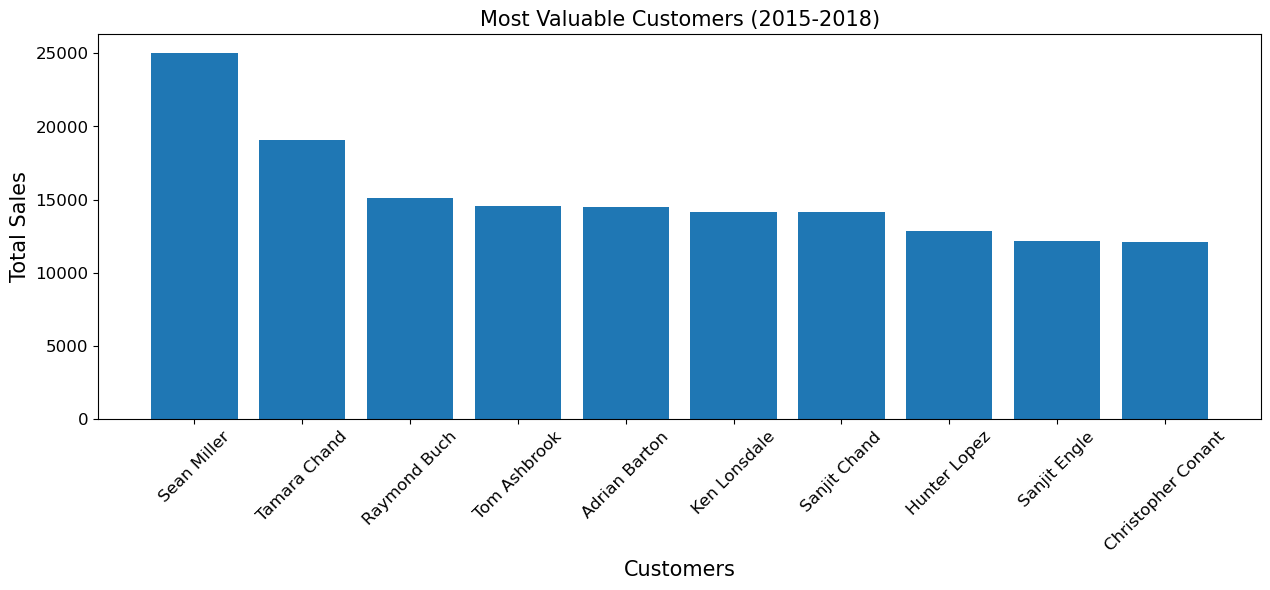

In [37]:
plot_maker(plot_title="Most Valuable Customers",x_label="Customers",x_rotate=45,bar_value=top10_customers)

In [61]:
total_percentage(top_customers,head_value=10)

                        Total  Percentage
Customer Name                            
Sean Miller         25043.050   16.281685
Tamara Chand        19052.218   12.386758
Raymond Buch        15117.339    9.828505
Tom Ashbrook        14595.620    9.489311
Adrian Barton       14473.571    9.409961
Ken Lonsdale        14175.229    9.215995
Sanjit Chand        14142.334    9.194608
Hunter Lopez        12873.298    8.369547
Sanjit Engle        12209.438    7.937940
Christopher Conant  12129.072    7.885690
All Sales Revenue $153,810


In [32]:
top_segment = top_in_year('Segment')

In [33]:
top_segment

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Total, dtype: float64

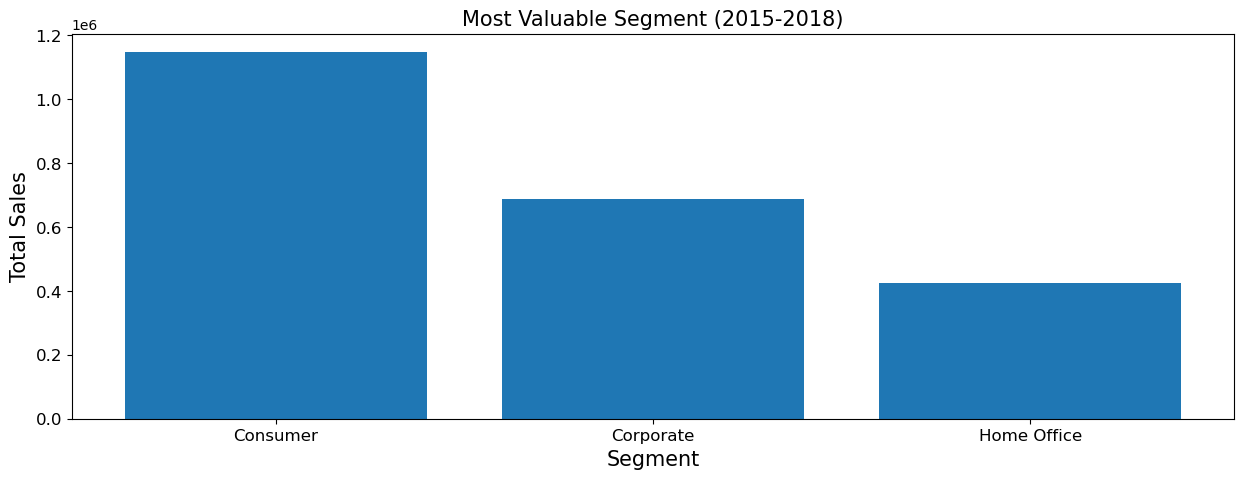

In [34]:
plot_maker(plot_title="Most Valuable Segment", x_label="Segment", bar_value=top_segment)

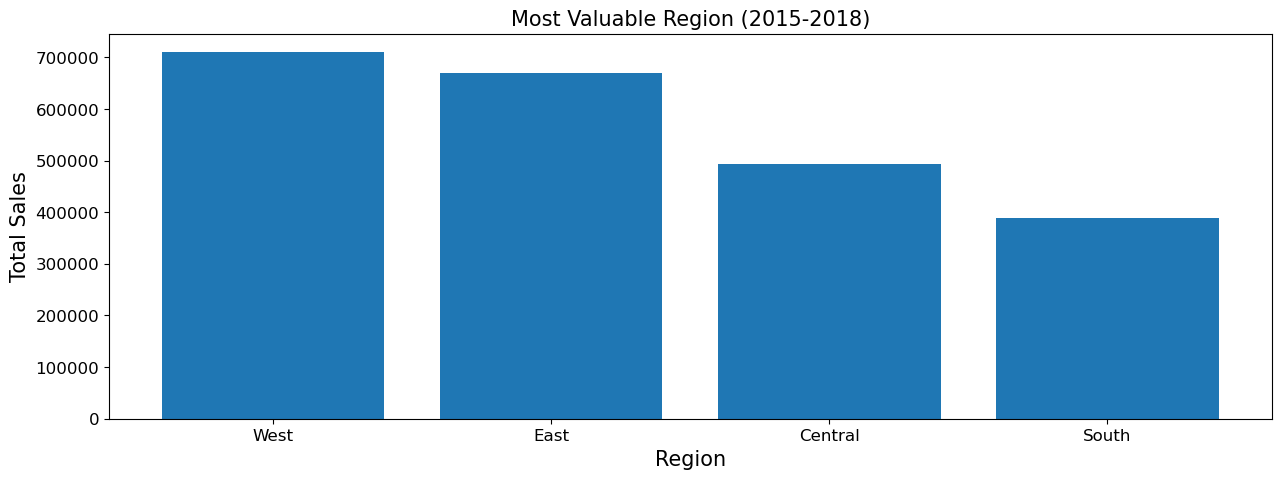

In [42]:
top_region = top_in_year("Region")
plot_maker(plot_title="Most Valuable Region", x_label="Region", bar_value=top_region)

In [62]:
total_percentage(top_region)

               Total  Percentage
Region                          
West     710219.6845   31.404295
East     669518.7260   29.604591
Central  492646.9132   21.783723
South    389151.4590   17.207390
All Sales Revenue $2,261,540


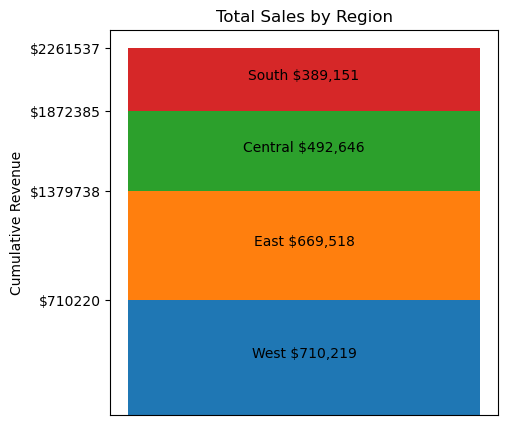

In [46]:
plt.figure(figsize = (5,5))
ax = plt.gca()
bottom = 0
count = 0
for region in top_region.index:
    ax.bar(1, top[region], label=region, bottom=bottom)
    bottom += top[region]
    ax.text(1,bottom-top[region]/2,f'{region} $'+ f'{int(top[region]):,d}', fontsize=10, horizontalalignment='center')
    count += 1
ax.set_title("Total Sales by Region")
ax.set_xlabel('')
ax.yaxis.set_major_formatter('${x:1.0f}')
ax.set_ylabel('Cumulative Revenue')
ax.set_xticks([])
ax.set_yticks(np.cumsum(list(top)));


In [47]:
top_cate = top_in_year('Category')

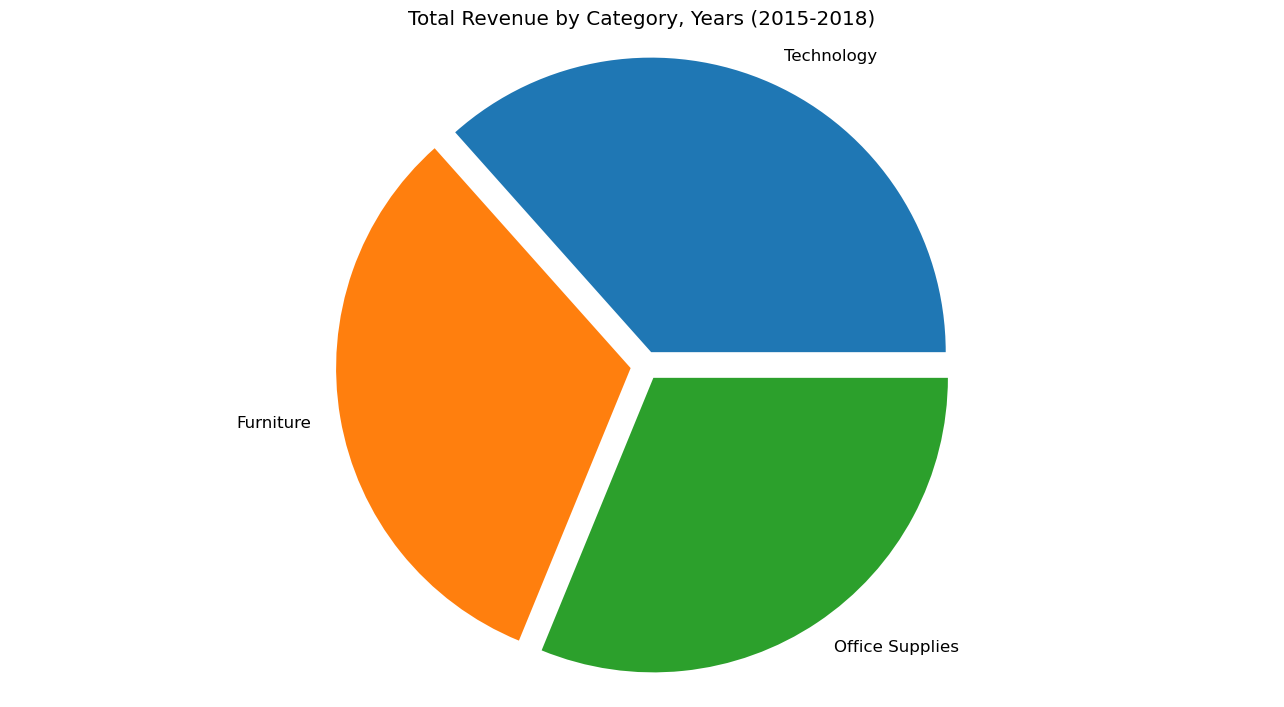

In [52]:
fig = plt.figure(figsize = (13,7))
ax1 = fig.gca()
plt.rcParams['font.size'] = 12.0
explode = len(top_cate.index) * [0.05]
ax1.pie(top_cate, labels=top_cate.index, explode=explode)
ax1.axis('equal')  
plt.tight_layout()
plt.title(f'Total Revenue by Category, Years ({min(years)}-{max(years)})')
plt.show();

In [63]:
total_percentage(top_cate)

                       Total  Percentage
Category                                
Technology       827455.8730   36.588212
Furniture        728658.5757   32.219621
Office Supplies  705422.3340   31.192167
All Sales Revenue $2,261,540


In [64]:
sub_cate = top_in_year('Sub-Category')

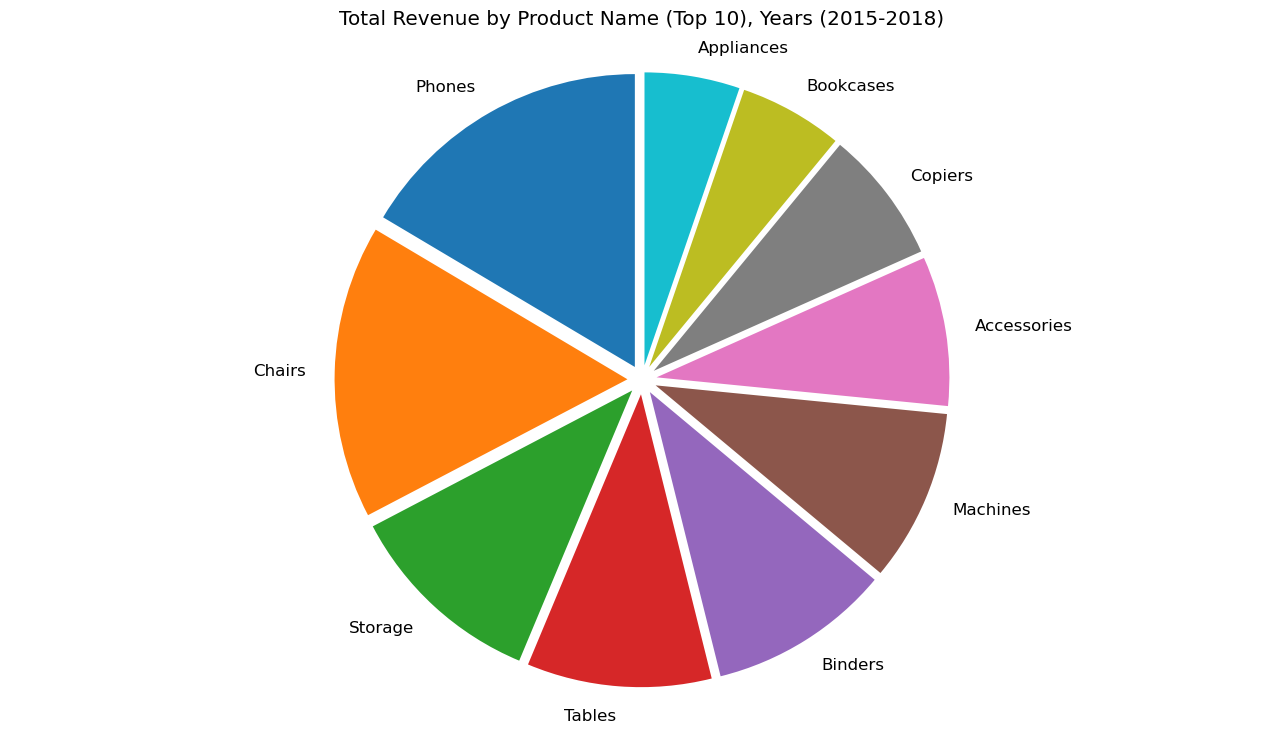

In [65]:
fig = plt.figure(figsize = (13,7))
ax1 = fig.gca()
plt.rcParams['font.size'] = 12.0
explode = len(sub_cate.index) * [0.05]
ax1.pie(sub_cate, labels=sub_cate.index, explode=explode, startangle=90)
ax1.axis('equal')  
plt.tight_layout()
plt.title(f'Total Revenue by Product Name (Top 10), Years ({min(years)}-{max(years)})', pad=20)
plt.show();